# Imports and Installations


In [ ]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from PIL import Image
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from typing import Tuple
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import torch.optim as optim
import torch.nn as nn
import torch
import numpy as np
import random
import warnings
import shutil
import os

warnings.filterwarnings('ignore')
matplotlib.style.use('ggplot')

In [ ]:
# For reproducibility
seed = 27
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)


# Loading and Analyzing the Dataset


In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
print("Please upload your kaggle.json file")
files.upload()

!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Please upload your kaggle.json file


Saving kaggle.json to kaggle.json


In [ ]:
# Replace 'dataset-owner/dataset-name' with the actual dataset path from Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/kaggle/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:21<00:00, 116MB/s]



In [ ]:
import zipfile
import os

zip_path = '/content/kaggle/chest-xray-pneumonia.zip' # Replace with the actual zip file name
extract_path = '/content/kaggle/chest_xray_extracted/' # Choose your extraction path

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

Dataset extracted to: /content/kaggle/chest_xray_extracted/


In [ ]:
dataset_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/'

train_path = f'{dataset_path}/train/'
val_path = f'{dataset_path}/val/'
test_path = f'{dataset_path}/test/'

In [ ]:
# The path where you extracted the files
extract_path = '/content/kaggle/chest_xray_extracted/'

# The actual dataset is usually inside a 'chest_xray' folder after extraction.
# This is the correct base path for your dataset in this Colab session.
dataset_path = os.path.join(extract_path, 'chest_xray')

# Define the final train, val, and test paths using the correct base path
train_path = os.path.join(dataset_path, 'train')
val_path = os.path.join(dataset_path, 'val')
test_path = os.path.join(dataset_path, 'test')

# Let's print the paths to confirm they are correct
print(f"Correct Dataset Path: {dataset_path}")
print(f"Correct Train Path: {train_path}")
print(f"Correct Val Path: {val_path}")
print(f"Correct Test Path: {test_path}")

Correct Dataset Path: /content/kaggle/chest_xray_extracted/chest_xray
Correct Train Path: /content/kaggle/chest_xray_extracted/chest_xray/train
Correct Val Path: /content/kaggle/chest_xray_extracted/chest_xray/val
Correct Test Path: /content/kaggle/chest_xray_extracted/chest_xray/test


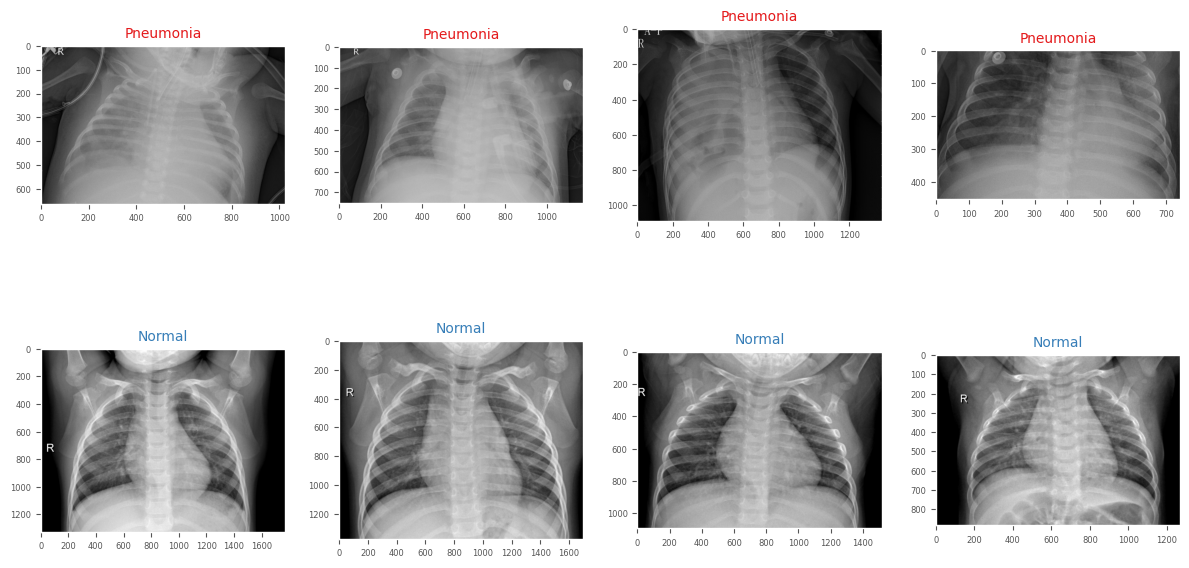

In [ ]:
random_pneumonia_samples = random.sample(os.listdir(f'{train_path}/PNEUMONIA'), 4)
random_non_pneumonia_samples = random.sample(os.listdir(f'{train_path}/NORMAL'), 4)

plt.rcParams['axes.grid'] = False
colors = sns.color_palette('Set1', 2)
fig, ax = plt.subplots(2, 4, figsize=(12, 7))
ax = ax.flatten()

for i in range(4):
    filename = random_pneumonia_samples[i]
    image = Image.open(f'{train_path}/PNEUMONIA/{filename}')
    ax[i].imshow(image, cmap='gray')
    ax[i].set_title('Pneumonia', color=colors[0], fontsize=10)
    ax[i].tick_params(axis='both', which='major', labelsize=6)

for i in range(4, 8):
    filename = random_non_pneumonia_samples[i-4] # corrected index
    image = Image.open(f'{train_path}/NORMAL/{filename}')
    ax[i].imshow(image, cmap='gray')
    ax[i].set_title('Normal', color=colors[1], fontsize=10)
    ax[i].tick_params(axis='both', which='major', labelsize=6)


plt.tight_layout()
plt.show()

In [ ]:
def plot_label_distribution(train_path: str, val_path: str, test_path: str) -> None:
    plt.rcParams['axes.grid'] = True
    train_counts = [len(os.listdir(f'{train_path}/{cls}')) for cls in ['NORMAL', 'PNEUMONIA']]
    val_counts = [len(os.listdir(f'{val_path}/{cls}')) for cls in ['NORMAL', 'PNEUMONIA']]
    test_counts = [len(os.listdir(f'{test_path}/{cls}')) for cls in ['NORMAL', 'PNEUMONIA']]
    total_counts = [sum(x) for x in zip(train_counts, val_counts, test_counts)]

    total_train = sum(train_counts)
    total_val = sum(val_counts)
    total_test = sum(test_counts)
    total_images = sum(total_counts)

    fig, ax = plt.subplots(1, 4, figsize=(14, 5))
    bars0 = ax[0].bar(['Normal', 'Pneumonia'], train_counts, color=colors)
    ax[0].set_title('Train')
    ax[0].set_ylabel('Number of images')
    bars1 = ax[1].bar(['Normal', 'Pneumonia'], val_counts, color=colors)
    ax[1].set_title('Validation')
    bars2 = ax[2].bar(['Normal', 'Pneumonia'], test_counts, color=colors)
    ax[2].set_title('Test')
    bars3 = ax[3].bar(['Normal', 'Pneumonia'], total_counts, color=colors)
    ax[3].set_title('Total')

    def add_labels(bars, ax, total):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height,
                    f'{height} ({height / total:.1%})',
                    ha='center', va='bottom')

    add_labels(bars0, ax[0], total_train)
    add_labels(bars1, ax[1], total_val)
    add_labels(bars2, ax[2], total_test)
    add_labels(bars3, ax[3], total_images)

    plt.tight_layout()
    plt.show()

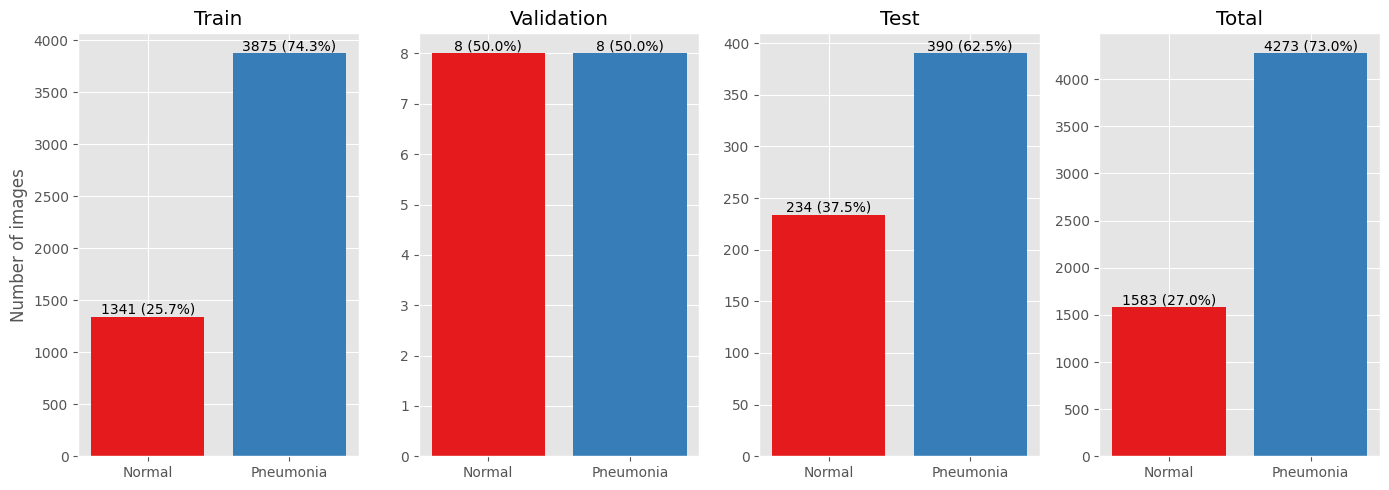

In [ ]:
plot_label_distribution(train_path, val_path, test_path)

# Re-splitting the dataset

In [ ]:
new_dataset_path = '/kaggle/working/chest_xray_new/'
new_train_path = f'{new_dataset_path}/train/'
new_val_path = f'{new_dataset_path}/val/'
new_test_path = f'{new_dataset_path}/test/'

if not os.path.exists(new_dataset_path):
    for split in ['train', 'val', 'test']:
        for cls in ['NORMAL', 'PNEUMONIA']:
            os.makedirs(f'{new_dataset_path}/{split}/{cls}', exist_ok=True)

    for cls in ['NORMAL', 'PNEUMONIA']:
        all_files = []
        for split in ['train', 'val', 'test']:
            source_folder = f'{dataset_path}/{split}/{cls}'
            files = os.listdir(source_folder)
            all_files.extend([(file, source_folder) for file in files])

        random.shuffle(all_files)

        train_files = all_files[:int(len(all_files)*0.8)]
        val_files = all_files[int(len(all_files)*0.8):int(len(all_files)*0.9)]
        test_files = all_files[int(len(all_files)*0.9):]

        for file, source_folder in train_files:
            dest = f'{new_dataset_path}/train/{cls}/{file}'
            shutil.copy(f'{source_folder}/{file}', dest)

        for file, source_folder in val_files:
            dest = f'{new_dataset_path}/val/{cls}/{file}'
            shutil.copy(f'{source_folder}/{file}', dest)

        for file, source_folder in test_files:
            dest = f'{new_dataset_path}/test/{cls}/{file}'
            shutil.copy(f'{source_folder}/{file}', dest)

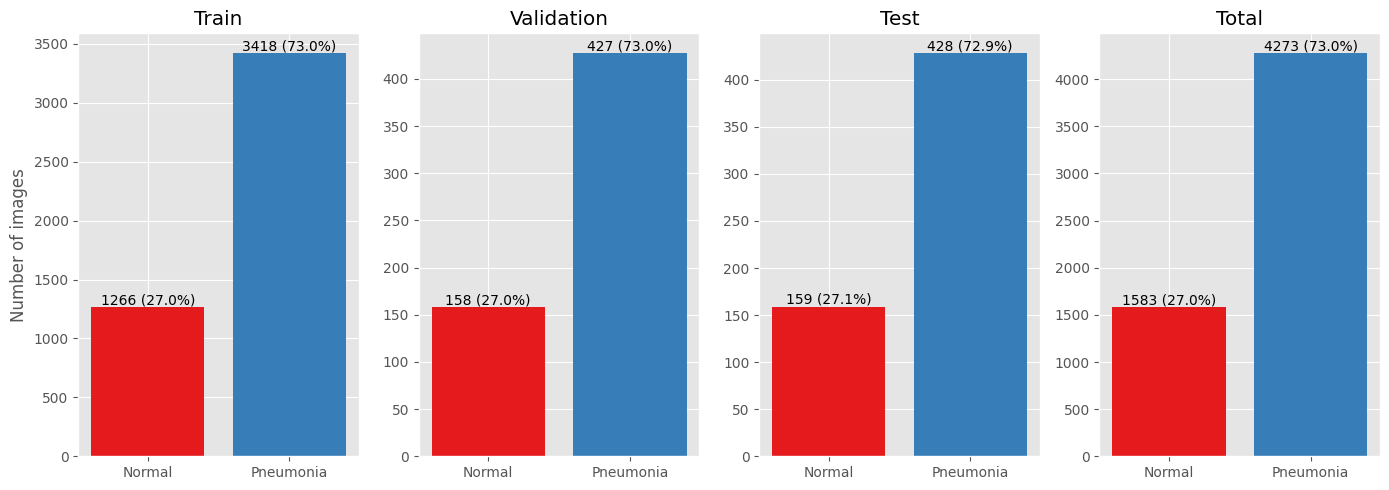

In [ ]:
plot_label_distribution(new_train_path, new_val_path, new_test_path)

# Creating Datasets and Dataloaders for Training


In [ ]:


IMAGE_SIZE = (299, 299)
BATCH_SIZE = 16
NUM_WORKERS = 4
DATA_TYPES = ['train', 'val', 'test']

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomHorizontalFlip(p=0.2),
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.4822, 0.4822, 0.4822], [0.2362, 0.2362, 0.2362])
    ]),
    'val': transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.4822, 0.4822, 0.4822], [0.2362, 0.2362, 0.2362])
    ]),
    'test': transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.4822, 0.4822, 0.4822], [0.2362, 0.2362, 0.2362])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(new_dataset_path, x), data_transforms[x]) for x in DATA_TYPES}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS) for x in DATA_TYPES}
dataset_sizes = {x: len(image_datasets[x]) for x in DATA_TYPES}
class_names = image_datasets['train'].classes

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
import os
print(os.listdir(f'{test_path}/PNEUMONIA')[:20]) # Print the first 20 filenames as an example

['person38_virus_83.jpeg', 'person65_virus_123.jpeg', 'person134_bacteria_643.jpeg', 'person78_bacteria_386.jpeg', 'person1667_virus_2881.jpeg', 'person139_bacteria_666.jpeg', 'person121_bacteria_580.jpeg', 'person173_bacteria_829.jpeg', 'person120_bacteria_572.jpeg', 'person128_bacteria_607.jpeg', 'person94_bacteria_456.jpeg', 'person93_bacteria_453.jpeg', 'person124_bacteria_590.jpeg', 'person138_bacteria_658.jpeg', 'person8_virus_28.jpeg', 'person83_bacteria_410.jpeg', 'person83_bacteria_407.jpeg', 'person100_bacteria_477.jpeg', 'person135_bacteria_647.jpeg', 'person16_virus_47.jpeg']


In [ ]:
class Trainer:
    def __init__(
        self,
        device: str,
        model: torch.nn.Module,
        criterion: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        scheduler: torch.optim.lr_scheduler,
        train_dataloader: DataLoader,
        val_dataloader: DataLoader,
        test_dataloader: DataLoader,
        checkpoint_path: str,
        pneumonia_samples: list
    ):
        self.device = device
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.test_dataloader = test_dataloader
        self.checkpoint_path = checkpoint_path
        self.best_accuracy = 0.0
        self.best_model_path = None
        self.pneumonia_samples = pneumonia_samples

    def save_cam_samples(self, model: models.inception_v3, epoch_nr: int) -> None:
        # Use the actual target value for Pneumonia class (assuming 1 based on your dataset setup)
        targets = [1] * len(self.pneumonia_samples)

        # Correct target layer for Inception v3
        target_layer = [model.Mixed_7c]
        cam = GradCAM(model=model, target_layers=target_layer)

        plt.rcParams['axes.grid'] = False

        for i, image_path in enumerate(self.pneumonia_samples):
            try:
                image = Image.open(image_path).convert('RGB')
                image_tensor = transforms.ToTensor()(image).unsqueeze(0).to(self.device)

                # Prepare image for visualization (convert to numpy and handle channels)
                # Note: The visualization function expects a numpy image with channels last (H, W, C)
                # and values in the range [0, 1]
                original_image_for_viz = np.array(image) / 255.0

                targets_for_cam = [ClassifierOutputTarget(targets[i])]
                grayscale_cam = cam(input_tensor=image_tensor, targets=targets_for_cam)
                grayscale_cam = grayscale_cam[0, :]

                # Ensure the original image for visualization has the correct format (H, W, C)
                # The image_tensor has shape (1, C, H, W), we need (H, W, C) numpy array for show_cam_on_image
                visualization = show_cam_on_image(original_image_for_viz, grayscale_cam, use_rgb=True)

                filename = os.path.basename(image_path).split('.')[0]
                filetype = os.path.basename(image_path).split('.')[-1]
                plt.imshow(visualization)
                plt.axis('off')
                os.makedirs('samples', exist_ok=True) # Ensure 'samples' directory exists
                plt.savefig(f'samples/{filename}-cam-epoch-{epoch_nr}.{filetype}', bbox_inches='tight', pad_inches=0)
                plt.close()
            except FileNotFoundError:
                print(f"Warning: Sample image not found at {image_path}. Skipping CAM visualization for this sample.")
            except Exception as e:
                print(f"An error occurred while processing {image_path}: {e}")


    def train(self, current_epoch_nr: int) -> Tuple[float, float]:
        self.model.train()

        num_batches = len(self.train_dataloader)

        running_loss = 0.0
        n_corrects = 0
        total = 0

        if current_epoch_nr == 1:
            self.save_cam_samples(self.model, 0)

        loop = tqdm(self.train_dataloader, total=num_batches)
        for batch in loop:
            x, y = batch
            x, y = x.to(self.device), y.to(self.device)

            self.optimizer.zero_grad()

            y_hat = self.model(x)
            _, preds = torch.max(y_hat, 1)
            loss = self.criterion(y_hat, y)

            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * x.size(0)
            n_corrects += torch.sum(preds == y.data).data.item()
            total += y.size(0)

            loop.set_description(f'Epoch {current_epoch_nr}')
            loop.set_postfix(train_acc=round(n_corrects / total, 5),
                             train_loss=round(running_loss / total, 5))

        self.scheduler.step()

        train_accuracy = n_corrects / total
        train_loss = running_loss / num_batches

        return train_accuracy, train_loss

    def evaluate(self, current_epoch_nr: int) -> Tuple[float, float]:
        self.model.eval()

        num_batches = len(self.val_dataloader)

        running_loss = 0.0
        n_corrects = 0
        total = 0

        with torch.no_grad():
            loop = tqdm(self.val_dataloader, total=num_batches)
            for batch in loop:
                x, y = batch
                x, y = x.to(self.device), y.to(self.device)

                self.optimizer.zero_grad()

                y_hat = self.model(x)
                _, preds = torch.max(y_hat, 1)
                loss = self.criterion(y_hat, y)

                running_loss += loss.item() * x.size(0)
                n_corrects += torch.sum(preds == y.data).data.item()
                total += y.size(0)


                loop.set_description(f'Epoch {current_epoch_nr}')
                loop.set_postfix(val_acc=round(n_corrects / total, 5),
                                 val_loss=round(running_loss / total, 5))

        val_accuracy = n_corrects / total
        val_loss = running_loss / num_batches

        self.save_cam_samples(self.model, current_epoch_nr)
        if val_accuracy > self.best_accuracy:
            self.best_accuracy = val_accuracy
            checkpoint_name = f'epoch_{current_epoch_nr}_acc_{round(val_accuracy, 2)}.pth'
            torch.save(
                self.model.state_dict(),
                os.path.join(self.checkpoint_path, checkpoint_name)
            )
            self.best_model_path = os.path.join(self.checkpoint_path, checkpoint_name)

        return val_accuracy, val_loss

    def test(self) -> Tuple[float, float, list, list, models.inception_v3]:
        self.model.eval()

        num_batches = len(self.test_dataloader)

        running_loss = 0.0
        n_corrects = 0
        total = 0

        targets = []
        predictions = []

        with torch.no_grad():
            loop = tqdm(self.test_dataloader, total=num_batches)
            for batch in loop:
                x, y = batch
                x, y = x.to(self.device), y.to(self.device)

                y_hat = self.model(x)
                _, preds = torch.max(y_hat, 1)
                loss = self.criterion(y_hat, y)

                running_loss += loss.item() * x.size(0)
                n_corrects += torch.sum(preds == y.data).data.item()
                total += y.size(0)

                targets.extend(y.cpu().numpy())
                predictions.extend(preds.cpu().numpy())

                loop.set_description('Testing')
                loop.set_postfix(test_acc=round(n_corrects / total, 5),
                                 test_loss=round(running_loss / total, 5))

        test_accuracy = n_corrects / total
        test_loss = running_loss / num_batches

        print('\nTest Accuracy: ', test_accuracy)
        print('Test Loss: ', test_loss)

        self.model.load_state_dict(torch.load(self.best_model_path))

        return test_accuracy, test_loss, targets, predictions, self.model

# I will use these samples to visualize with Grad-CAM
# Update pneumonia_samples to use the correct test_path
pneumonia_samples = [
    os.path.join(test_path, 'PNEUMONIA', 'person158_bacteria_744.jpeg'),
    os.path.join(test_path, 'PNEUMONIA', 'person69_virus_129.jpeg'),
    os.path.join(test_path, 'PNEUMONIA', 'person78_bacteria_380.jpeg'),
    os.path.join(test_path, 'PNEUMONIA', 'person175_bacteria_833.jpeg'),
    os.path.join(test_path, 'PNEUMONIA', 'person100_bacteria_480.jpeg')
]

# Check if the sample files exist
for sample in pneumonia_samples:
    if not os.path.exists(sample):
        print(f"Error: Sample file not found at {sample}. Please check the test_path and filenames.")
        # You might want to exit or handle this error appropriately

os.makedirs('samples', exist_ok=True)
for sample in pneumonia_samples:
    try:
        img = Image.open(sample)
        img.save('samples/' + os.path.basename(sample))
    except FileNotFoundError:
        print(f"Warning: Could not save sample image {sample} to 'samples' directory as it was not found.")

# Training


In [ ]:
model = models.inception_v3()
n_features = model.fc.in_features
model.fc = nn.Linear(n_features, len(class_names))
model.aux_logits = False
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [ ]:
max_epochs = 10

train_dataloader = dataloaders['train']
val_dataloader = dataloaders['val']
test_dataloader = dataloaders['test']

checkpoint_path = '/kaggle/working/checkpoints'
try:
    os.mkdir(checkpoint_path)
except FileExistsError:
    pass


trainer = Trainer(
    device=device,
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    test_dataloader=test_dataloader,
    checkpoint_path=checkpoint_path,
    pneumonia_samples=pneumonia_samples
)

histories = []
for epoch in range(1, max_epochs + 1):
    train_acc, train_loss = trainer.train(current_epoch_nr=epoch)
    val_acc, val_loss = trainer.evaluate(current_epoch_nr=epoch)

    histories.append({
        'epoch': epoch,
        'train_acc': train_acc,
        'train_loss': train_loss,
        'val_acc': val_acc,
        'val_loss': val_loss
    })

test_acc, test_loss, targets, predictions, best_model = trainer.test()

Testing: 100%|██████████| 37/37 [00:10<00:00,  3.45it/s, test_acc=0.944, test_loss=0.138]



Test Accuracy:  0.9437819420783645
Test Loss:  2.1952132886225306


# Analyzing the Results


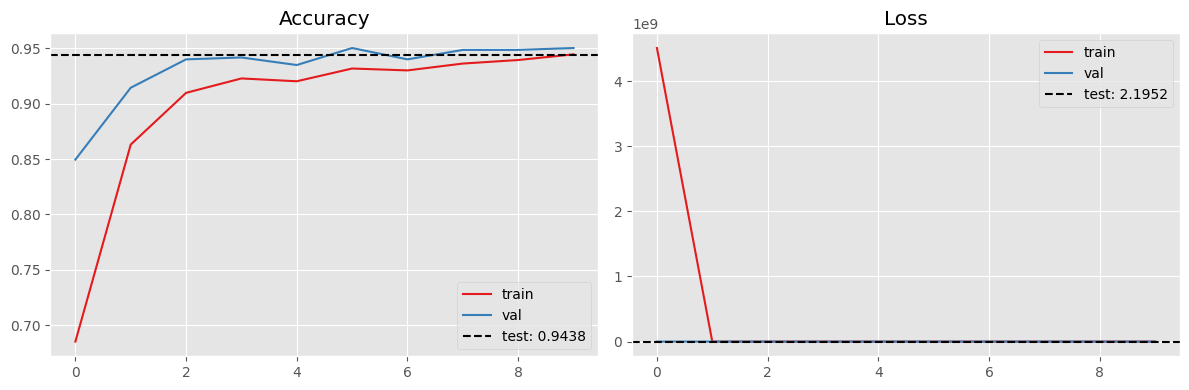

In [ ]:
train_accs = [x['train_acc'] for x in histories]
train_losses = [x['train_loss'] for x in histories]
val_accs = [x['val_acc'] for x in histories]
val_losses = [x['val_loss'] for x in histories]

plt.rcParams['axes.grid'] = True
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='train', color=colors[0])
plt.plot(val_accs, label='val', color=colors[1])
plt.axhline(y=test_acc, color='black', linestyle='--', label=f'test: {test_acc:.4f}')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='train', color=colors[0])
plt.plot(val_losses, label='val', color=colors[1])
plt.axhline(y=test_loss, color='black', linestyle='--', label=f'test: {test_loss:.4f}')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

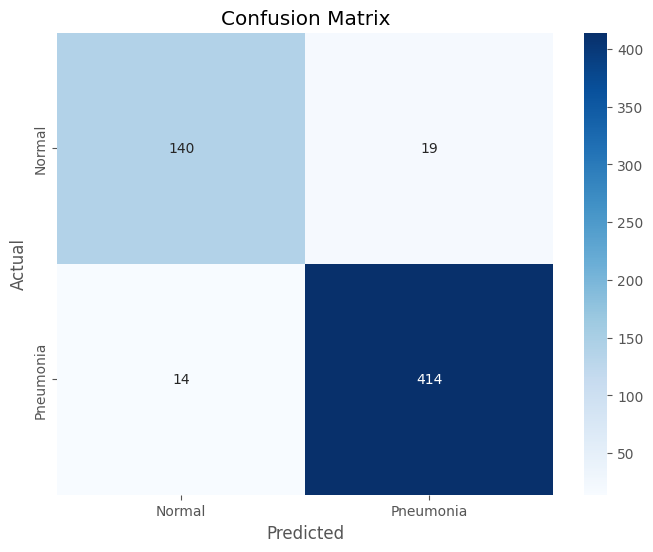

In [ ]:
cm = confusion_matrix(targets, predictions)

plt.rcParams['axes.grid'] = False
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(targets, predictions, target_names=['Normal', 'Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.91      0.88      0.89       159
   Pneumonia       0.96      0.97      0.96       428

    accuracy                           0.94       587
   macro avg       0.93      0.92      0.93       587
weighted avg       0.94      0.94      0.94       587



# Grad-CAM


In [ ]:


def plot_cam(model: models.resnet.ResNet, image_paths: list, targets: list) -> None:
    model = model.eval()

    target_layer = [model.Mixed_7c]
    cam = GradCAM(model=model, target_layers=target_layer)

    plt.rcParams['axes.grid'] = False
    fig, axs = plt.subplots(2, 4, figsize=(14, 7))

    for i, (image_path, target) in enumerate(zip(image_paths, targets)):
        image = Image.open(image_path).convert('RGB')
        image = transforms.ToTensor()(image)

        image_tensor = image.unsqueeze(0)

        image = image.numpy().transpose((1, 2, 0))
        image = np.clip(image, 0, 1)

        targets = [ClassifierOutputTarget(target)]
        grayscale_cam = cam(input_tensor=image_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        visualization = show_cam_on_image(np.array(image_tensor[0].permute(1, 2, 0)), grayscale_cam, use_rgb=True)

        axs[1, i].imshow(image)
        axs[1, i].set_title('Original')
        axs[1, i].tick_params(axis='both', which='major', labelsize=6)

        axs[0, i].imshow(visualization)
        axs[0, i].set_title('Grad-CAM')
        axs[0, i].tick_params(axis='both', which='major', labelsize=6)

    plt.tight_layout()
    plt.show()


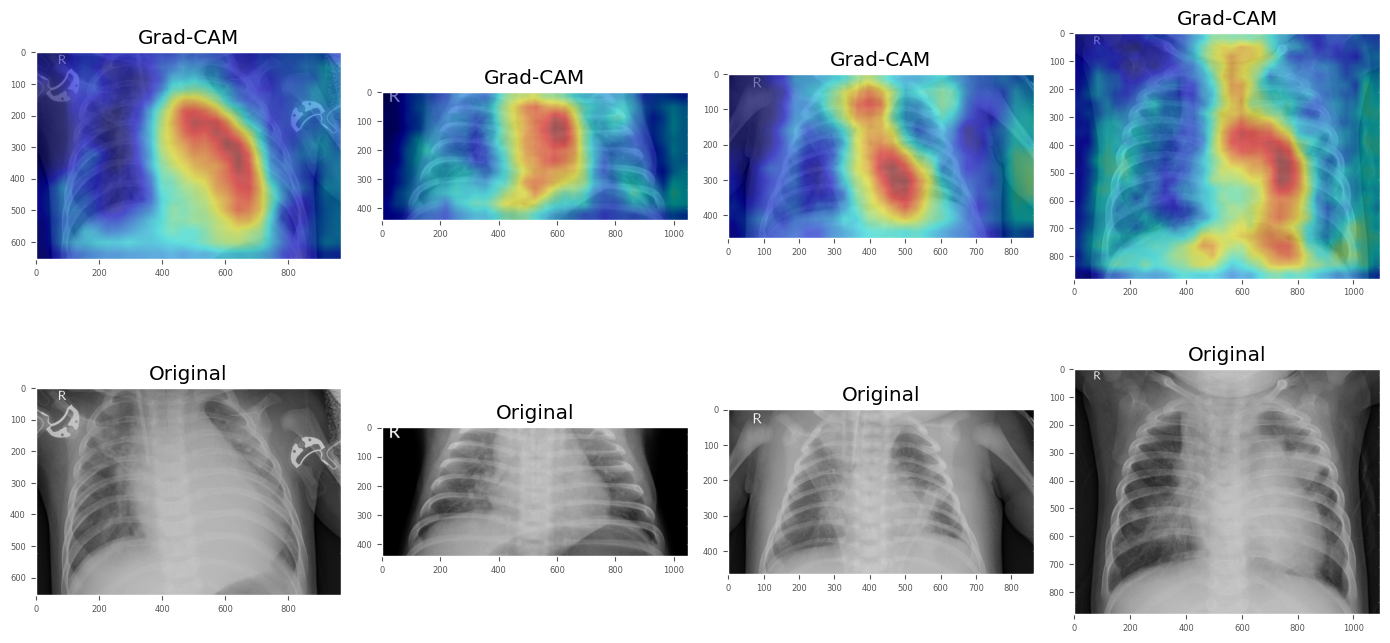

In [ ]:
image_paths = pneumonia_samples
plot_cam(best_model, image_paths, [1] * 4)

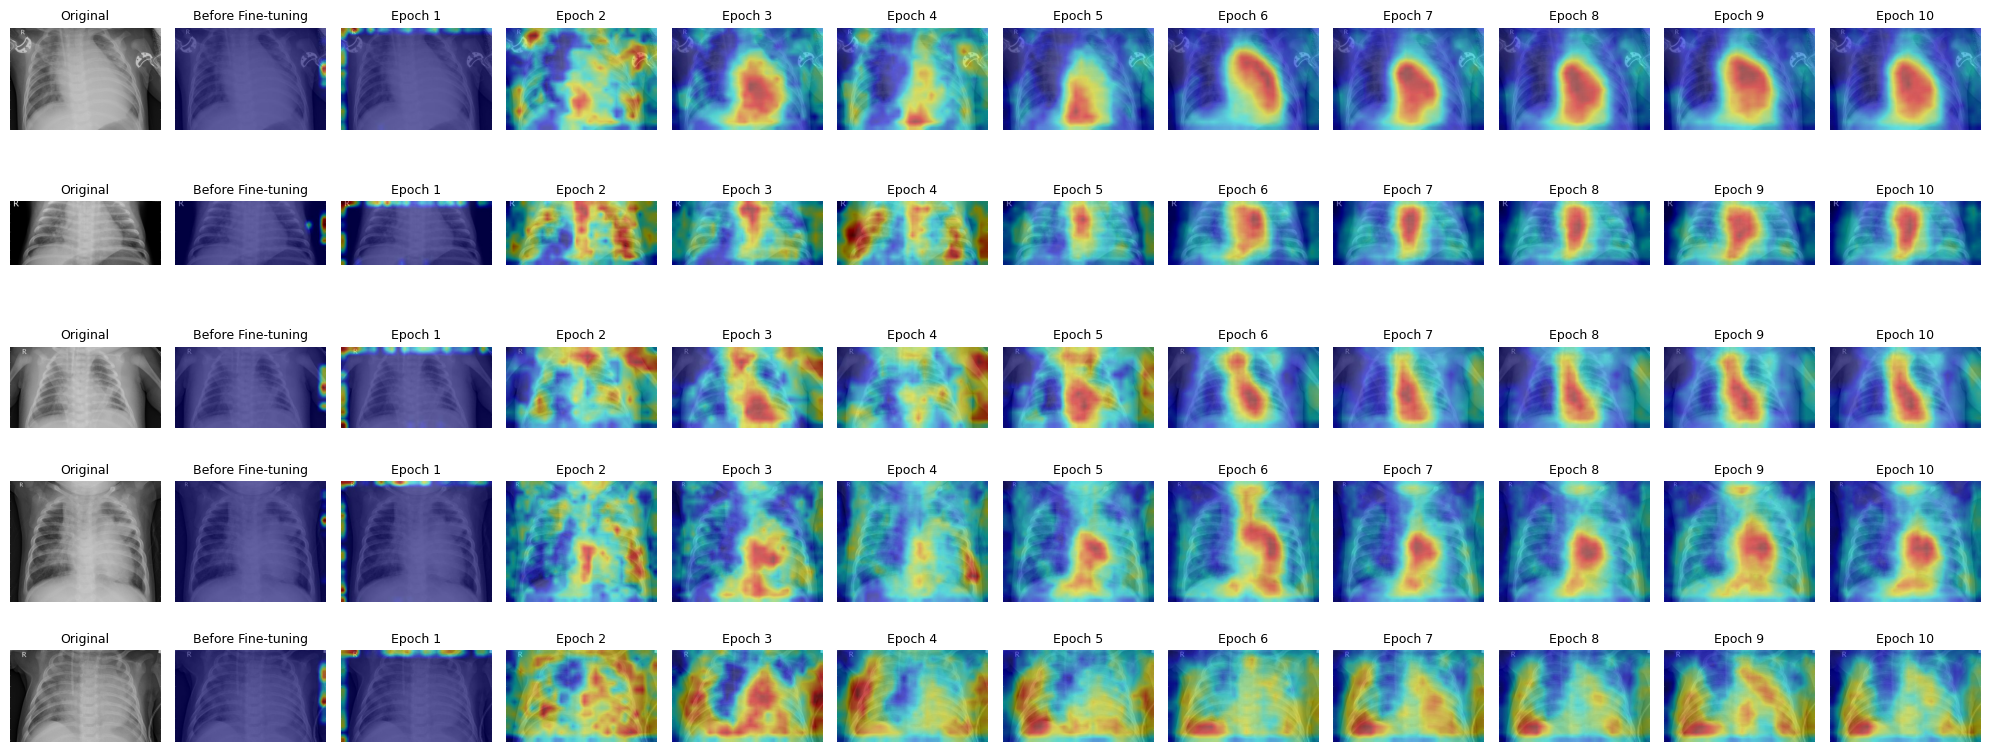

In [ ]:
fig, axs = plt.subplots(len(pneumonia_samples), max_epochs + 2, figsize=(20, 8))
start_index = 0
for row in range(len(pneumonia_samples)):
    filename = Image.open(pneumonia_samples[start_index])
    axs[row, 0].imshow(filename, cmap='gray')
    axs[row, 0].set_title('Original', fontsize=9)
    axs[row, 0].axis('off')
    start_index += 1

    original_filename = filename.filename.split('/')[-1].split('.')[0]

    for col in range(1, max_epochs + 2):
        filename = Image.open(f'/content/samples/{original_filename}-cam-epoch-{col-1}.jpeg')
        axs[row, col].imshow(filename, cmap='gray')
        if col == 0:
            title = 'Original'
        if col == 1:
            title = 'Before Fine-tuning'
        if col > 1:
            title = f'Epoch {col - 1}'
        axs[row, col].set_title(title, fontsize=9)
        axs[row, col].axis('off')


plt.tight_layout()
plt.show()